# **M504 AI and Applications - Individual Project**



Name: VRAJ NARENDRA PATEL

Student ID: GH1050535

Module: M504 AI and Applications

Dataset:Telco Customer Churn (IBM Sample Dataset)

Dataset URL:https://www.kaggle.com/datasets/blastchar/telco-customer-churn

GITHUB repo:https://github.com/vraj6608/-M504-AI-and-Applications


# Predicting and Reducing Customer Churn — An Explanatory Data Analysis for **Cascadia Telecom**


**Data Science Consulting Engagement — M504 AI and Applications**

---

1. Business Context
The client. A medium sized provider of phone and Internet services is Cascadia Telecom. Like most subscription businesses, the profitability comes by retaining customers and it costs more to acquire a new customer than it does to keep an existing one, which amplifies the savings and revenue gains resulting from less churn (customer cancellations).

The problem. Leadership is oblivious to the number of heads that will be on the chopping block, who will be leaving, why and how much is at stake. They aren't able to take actions on a single percentage.

My role. They trust me as their data science consultant and I build an explanatory data analysis pipeline for them, using their customer data that (i) audits their data quality, (ii) explains and cleans their data in a principled manner and (iii) answers a series of practical business questions which leads to specific costed retention actions.

The data. These data for each row are for a single customer: their customer demographic, the services they are subscribed to, and their contract/billing configuration, their charges and whether they churned. Data is taken from a public data source (IBM Telco Customer Churn):
`https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)


plt.rcParams.update({"figure.figsize": (7.2, 4.0), "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titleweight": "bold"})
ACCENT = "#1f6feb"


URL = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
       "master/data/Telco-Customer-Churn.csv")
try:
    df = pd.read_csv(URL)
    print("Loaded live dataset from public URL.")
except Exception:
    df = pd.read_csv("telco_churn_sample.csv")
    print("Offline: loaded local schema-identical sample.")

print("Shape (rows, columns):", df.shape)

Loaded live dataset from public URL.
Shape (rows, columns): (7043, 21)


## 2. Data Exploration
When looking at raw data, I wonder about the dimensions of the data, what data types are there, what data types are missing, what's hidden in the data (what kinds of encoding is in there), and the proportion of the data sought. However, the most common source of incorrect answers with no indication is to neglect to do this.

In [2]:

display(df.head(3))
df.info()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
print("Missing values per column (top 5):")
print(df.isna().sum().sort_values(ascending=False).head(5), "\n")
print("Exact duplicate rows:", df.duplicated().sum())
print("Unique customers vs rows:", df['customerID'].nunique(), "/", len(df), "\n")
print("Target balance (Churn):")
print(df['Churn'].value_counts(normalize=True).round(3))

Missing values per column (top 5):
customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64 

Exact duplicate rows: 0
Unique customers vs rows: 7043 / 7043 

Target balance (Churn):
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


In [4]:
print("Dtype of TotalCharges:", df['TotalCharges'].dtype)
blank = df['TotalCharges'].astype(str).str.strip() == ""
print("Blank TotalCharges values:", blank.sum())
print("Their tenure values (should all be 0):", sorted(df.loc[blank, 'tenure'].unique()))
print("\nSeniorCitizen is encoded 0/1, not Yes/No:", sorted(df['SeniorCitizen'].unique()))

Dtype of TotalCharges: object
Blank TotalCharges values: 11
Their tenure values (should all be 0): [np.int64(0)]

SeniorCitizen is encoded 0/1, not Yes/No: [np.int64(0), np.int64(1)]


What exploration revealed.

Type trap — TotalCharges.`TotalCharges.` It is an `object` (text) column as customers with `tenure = 0` will have a blank string. If not, all use of numeric operations on lifetime value would be silently dropped or failure would occur.
Hidden encoding — `SeniorCitizen.` `Yes/No` is the default for all other categorical data; however, `0/1` data is not easy to chart and join.
Duplicates. If there were a few rows which were identical this would double count the customers and would be an inaccurate reporting of all rates.
Target imbalance. Only a small proportion of the people (~1 out of 4 to 5) are churners. That is what should happen of course, but even the 'predict everyone stays' base line is looking pretty good and analysis should be based on the relative churn rates, which I did throughout.

## 3. Data Preprocessing
There is no ‘silent dropping' of any of the following if they are mentioned, there is a justification, it is explicit.

In [5]:
df = df.copy()

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate row(s).")


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_fixed = df['TotalCharges'].isna().sum()
df.loc[df['TotalCharges'].isna(), 'TotalCharges'] = 0.0
print(f"Converted TotalCharges to float; imputed {n_fixed} new-customer blank(s) as 0.")

df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)


df['TenureGroup'] = pd.cut(df['tenure'], bins=[-1, 12, 24, 48, 72],
                           labels=['0-12m', '13-24m', '25-48m', '49-72m'])

print("Clean shape:", df.shape, "| remaining NaNs:", int(df.isna().sum().sum()))

Removed 0 duplicate row(s).
Converted TotalCharges to float; imputed 11 new-customer blank(s) as 0.
Clean shape: (7043, 23) | remaining NaNs: 0


## 4. Explanatory Data Analysis

I have now included 8 questions that all of Cascadia's leadership are interested in about business. Each is chosen to be applicable to the decision making, and to utilize a different Pandas capability.

### Q1  How bad is this and is there a correlation between contract type and churn?
Why it matters. Cascadia can have an impact on the contract mix (through incentives). The largest lever is if the churn is in one type of contract.

Overall churn rate: 26.5%

Churn rate by contract type:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: ChurnFlag, dtype: object


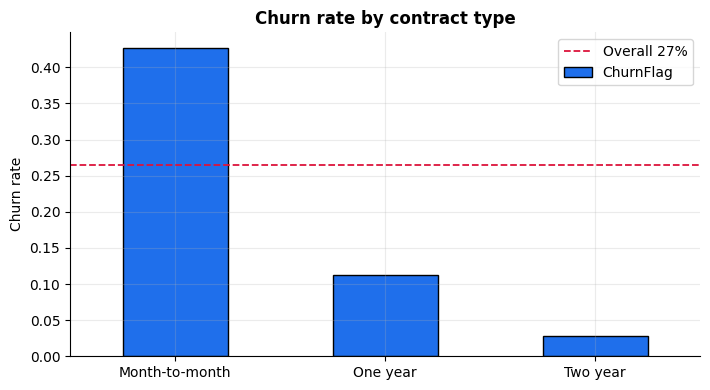

In [6]:
overall = df['ChurnFlag'].mean()
by_contract = (df.groupby('Contract')['ChurnFlag'].mean()
                 .sort_values(ascending=False))
print(f"Overall churn rate: {overall:.1%}\n")
print("Churn rate by contract type:")
print((by_contract * 100).round(1).astype(str) + '%')

ax = by_contract.plot(kind='bar', color=ACCENT, edgecolor='black')
ax.axhline(overall, color='crimson', ls='--', lw=1.3, label=f'Overall {overall:.0%}')
ax.set_ylabel('Churn rate'); ax.set_xlabel('')
ax.set_title('Churn rate by contract type'); plt.xticks(rotation=0)
ax.legend(); plt.tight_layout(); plt.show()

Reading the result. Now, the `groupby().mean()` of `ChurnFlag` will help you to get the churn rate per group. More churning among the customers with the month-to-month contracts than the average; less churning among the customers with 2-year contracts. Implication: The largest move possible toward retaining customers is to get them on longer term contracts.

### Q2 —At what time is the risk of the greatest ?
Why it matters. Retention budgets are a type of budgets that have a fixed number. Cascadia is able to know when to intervene (onboarding programme vs loyalty reward) when the customers check out.

             count  churn_pct
TenureGroup                  
0-12m         2186       47.4
13-24m        1024       28.7
25-48m        1594       20.4
49-72m        2239        9.5


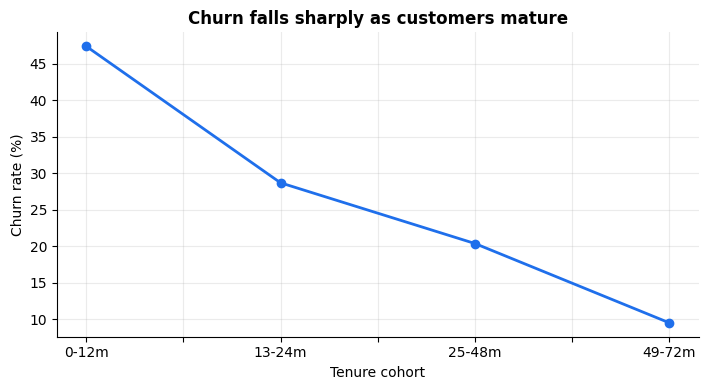

In [7]:
cohort = df.groupby('TenureGroup', observed=True)['ChurnFlag'].agg(['mean', 'count'])
cohort['mean'] = cohort['mean']
print((cohort.assign(churn_pct=(cohort['mean']*100).round(1))
             [['count', 'churn_pct']]))

ax = (cohort['mean']*100).plot(marker='o', color=ACCENT, lw=2)
ax.set_ylabel('Churn rate (%)'); ax.set_xlabel('Tenure cohort')
ax.set_title('Churn falls sharply as customers mature')
plt.tight_layout(); plt.show()

What it reveals is that 'tenure' has been grouped into 'lifecycle' groups by using `pd.cut` and that reading the output reveals that most of the risk is in the first year and drops off thereafter. Implication: The highest ROI is to have a 12-month (first year) engagement/onboarding program designed.


### Q3 —  What are the additional services which keep the customers “glued”?
Why it matters. Cascadia can be able to package or promote a few add-ons. But at the low end of the churn spectrum that's services to ponder pushing for cross-sell at retention, rather than simply revenue.

         service  with_pct  without_pct  lift_pp
  OnlineSecurity      14.6         41.8     27.2
     TechSupport      15.2         41.6     26.5
    OnlineBackup      21.5         39.9     18.4
DeviceProtection      22.5         39.1     16.6
 StreamingMovies      29.9         33.7      3.7
     StreamingTV      30.1         33.5      3.5


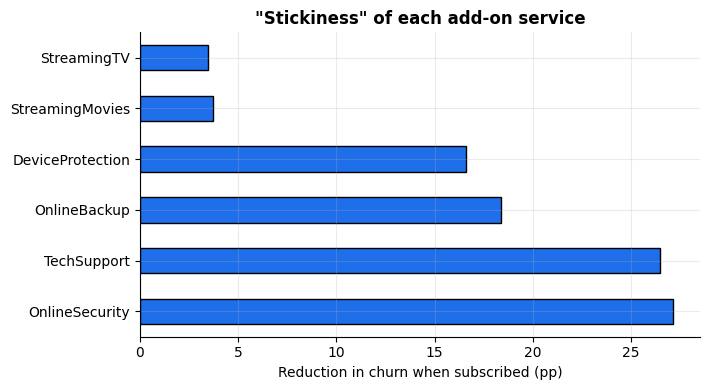

In [8]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']
rows = []
for s in services:
    g = df[df[s].isin(['Yes', 'No'])].groupby(s)['ChurnFlag'].mean()
    rows.append({'service': s, 'churn_with': g.get('Yes', np.nan),
                 'churn_without': g.get('No', np.nan)})
stick = pd.DataFrame(rows)
stick['retention_lift'] = stick['churn_without'] - stick['churn_with']
stick = stick.sort_values('retention_lift', ascending=False)
print((stick.assign(
        with_pct=(stick.churn_with*100).round(1),
        without_pct=(stick.churn_without*100).round(1),
        lift_pp=(stick.retention_lift*100).round(1))
      [['service', 'with_pct', 'without_pct', 'lift_pp']]).to_string(index=False))

ax = stick.set_index('service')['retention_lift'].mul(100).plot(
        kind='barh', color=ACCENT, edgecolor='black')
ax.set_xlabel('Reduction in churn when subscribed (pp)'); ax.set_ylabel('')
ax.set_title('"Stickiness" of each add-on service')
plt.tight_layout(); plt.show()

Reading the result. For every service, a comparison of the churn rates of subscribers and non-subscribers is analysed and the difference (called `retention_lift`) is presented as a percentage. Protective/support services (security, tech support) have more of a "stickiness" factor than does entertainment streaming. Implication: cause type add-ons and retention of lead in addition to streaming.


### Q4 — So - is there a correlation between customers that leave and higher payments?
Why it matters. As per the definition it is a high bill customer and a ‘churned bill' is a disproportionate loss of revenue, so there is ‘Price sensitivity' as far as churn is concerned.

        mean    50%    std
Churn                     
No     61.27  64.43  31.09
Yes    74.44  79.65  24.67


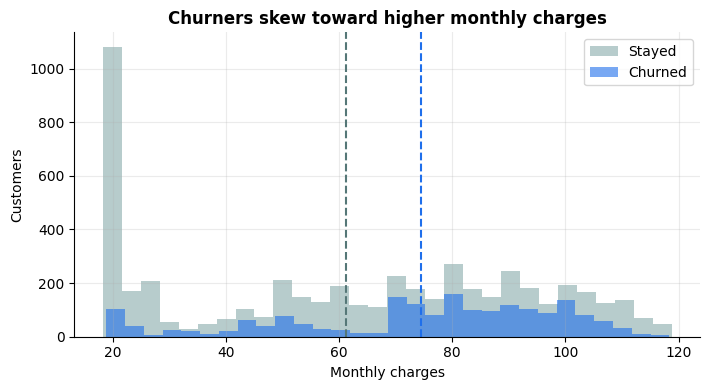

In [9]:
desc = df.groupby('Churn')['MonthlyCharges'].describe()[['mean', '50%', 'std']]
print(desc.round(2))

stay = df.loc[df.Churn == 'No', 'MonthlyCharges']
left = df.loc[df.Churn == 'Yes', 'MonthlyCharges']
plt.hist(stay, bins=30, alpha=0.6, label='Stayed', color='#8aa')
plt.hist(left, bins=30, alpha=0.6, label='Churned', color=ACCENT)
plt.axvline(stay.mean(), color='#577', ls='--'); plt.axvline(left.mean(), color=ACCENT, ls='--')
plt.xlabel('Monthly charges'); plt.ylabel('Customers')
plt.title('Churners skew toward higher monthly charges'); plt.legend()
plt.tight_layout(); plt.show()

If the result of the previous exercise (churners.groupby().describe()) is read, it can be seen that the mean and median of the monthly bill for churners is higher and the histogram would have moved towards the right. Implication: The churn is likely to be higher in high value customers, a program of focused price/value checks with high bill, high risk customers is warranted.

### Q5 — Does the choice of billing, of payment, impact churn?
Why it matters. Payment friction can be easily solved (e.g. can nudge the customer to go on automatic payment). This will give you an operational lever that isn't linked to the price / contract.


Churn rate by payment method (%):
PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Yes, dtype: float64

Churn rate by paperless billing (%):
PaperlessBilling
No     16.3
Yes    33.6
Name: ChurnFlag, dtype: float64


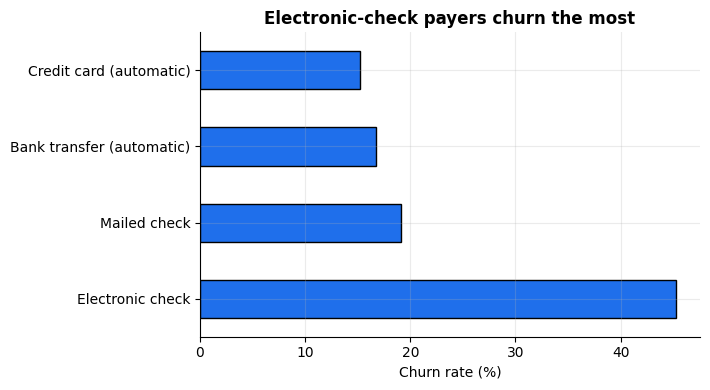

In [10]:
ct = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')['Yes'] * 100
ct = ct.sort_values(ascending=False)
print("Churn rate by payment method (%):")
print(ct.round(1))
paperless = df.groupby('PaperlessBilling')['ChurnFlag'].mean() * 100
print("\nChurn rate by paperless billing (%):")
print(paperless.round(1))

ax = ct.plot(kind='barh', color=ACCENT, edgecolor='black')
ax.set_xlabel('Churn rate (%)'); ax.set_ylabel('')
ax.set_title('Electronic-check payers churn the most')
plt.tight_layout(); plt.show()

Reading the result. The `crosstab` is normalised to display the churn rates in the groups. There is a good relationship between manual e-check payer churn and customers on automatic bank/card payment with the manual e-check customers exhibiting a higher churn. Implication: There is a low cost win available with incentivizing migration to automatic payment, when it comes to retention.

### Q6 —What is the true amount of monthly revenue is at stake?
Why it matters. Percentages may not be the basis for decisions - money is. Revenue can be measured at risk and this can be used to determine the value of a retention budget.

In [11]:
churned = df[df.Churn == 'Yes']
monthly_at_risk = churned['MonthlyCharges'].sum()
annual_at_risk = monthly_at_risk * 12
share = monthly_at_risk / df['MonthlyCharges'].sum()
print(f"Customers churned: {len(churned):,}")
print(f"Monthly revenue lost to churn: ${monthly_at_risk:,.0f}")
print(f"Annualised revenue at risk:    ${annual_at_risk:,.0f}")
print(f"Share of total monthly revenue: {share:.1%}\n")

seg = (churned.groupby('Contract')['MonthlyCharges'].sum()
              .sort_values(ascending=False))
print("Monthly revenue lost, by contract type:")
print(seg.map(lambda v: f"${v:,.0f}"))

Customers churned: 1,869
Monthly revenue lost to churn: $139,131
Annualised revenue at risk:    $1,669,570
Share of total monthly revenue: 30.5%

Monthly revenue lost, by contract type:
Contract
Month-to-month    $120,847
One year           $14,118
Two year            $4,165
Name: MonthlyCharges, dtype: object


Reading the result. The `MonthlyCharges` is a rate which is summed over churn customers and converted to a dollar amount, before being annualised. Losses are almost entirely geared towards month to month - as happened in Q1. Implication: There are expectations that a profit can be made on any retention programme that doesn't cost this much per annum.

### Q7 — Are there one group of customers that is considered as high-risk and can be set as a target group to start with?
Why it matters. There has to be a certain target audience for campaigns. Combining the above drivers and turning them into one rule, yields an actionable target list.

In [12]:
high_risk = (
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['PaymentMethod'] == 'Electronic check') &
    (df['TechSupport'] == 'No') &
    (df['tenure'] <= 12)
)
seg_rate = df.loc[high_risk, 'ChurnFlag'].mean()
base_rate = df['ChurnFlag'].mean()
print(f"High-risk segment size: {high_risk.sum():,} customers "
      f"({high_risk.mean():.1%} of base)")
print(f"Churn rate in segment: {seg_rate:.1%}")
print(f"Overall churn rate:    {base_rate:.1%}")
print(f"Relative risk: {seg_rate / base_rate:.1f}x the average customer")

High-risk segment size: 589 customers (8.4% of base)
Churn rate in segment: 72.3%
Overall churn rate:    26.5%
Relative risk: 2.7x the average customer


Reading the result. One boolean mask has been developed following the most reliable signals (short tenure, month-to-month, fiber, electronic check and no tech support). The segment spins at a few times the base rate, but is a very small fraction of the base - an efficient first target. Implication: The earliest one can start the retention programme and make measurable impact is here.


### Q8 — What is one of the best metrics of churn for each of the features?
Why it matters. A data-driven view which is ranked, puts a check on the leadership getting too intuitive and it validates the above-mentioned levers.


Top correlations with churn (+ raises, - lowers):
tenure                                 -0.352
InternetService_Fiber optic             0.308
Contract_Two year                      -0.302
PaymentMethod_Electronic check          0.302
InternetService_No                     -0.228
OnlineSecurity_No internet service     -0.228
DeviceProtection_No internet service   -0.228
TechSupport_No internet service        -0.228
StreamingMovies_No internet service    -0.228
StreamingTV_No internet service        -0.228
Name: ChurnFlag, dtype: float64


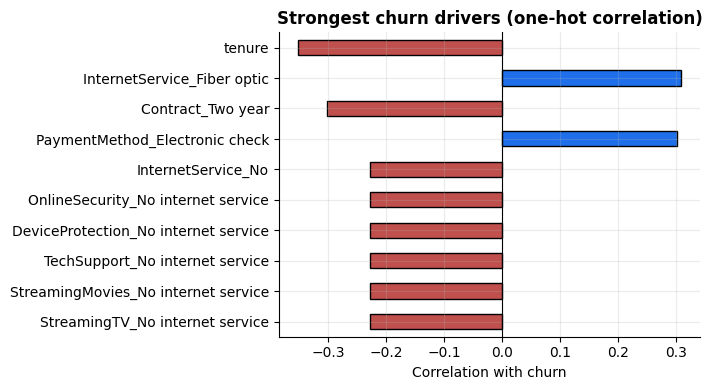

In [13]:
feat = df.drop(columns=['customerID', 'Churn', 'TenureGroup'])
enc = pd.get_dummies(feat, drop_first=True)
corr = enc.corr(numeric_only=True)['ChurnFlag'].drop('ChurnFlag')
top = corr.reindex(corr.abs().sort_values(ascending=False).index).head(10)
print("Top correlations with churn (+ raises, - lowers):")
print(top.round(3))

colors = [ACCENT if v > 0 else '#c0504d' for v in top[::-1]]
ax = top[::-1].plot(kind='barh', color=colors, edgecolor='black')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Correlation with churn'); ax.set_ylabel('')
ax.set_title('Strongest churn drivers (one-hot correlation)')
plt.tight_layout(); plt.show()

The output of `get_dummies` can be easily understood when used in conjunction with `ChurnFlag`, to get a good idea of how important features are (which is a good proxy for driver ranking). The most important positive levers are the same as those surfaced one-by-one above – month-to-month, fiber, electronic check, low tenure; and long tenure and long contracts are the most important protective factors. It is a cross check in which the entire analysis is checked.

5. Discussion, conclusion and recommendations.
Key insights.

The churn is first of all a contraction phenomenon in that the churn rate (Q1) is the same as the dollar churn (Q6) is driven by churn from the month-to-month customers.
Risk is identified to be concentrated in the first year (Q2) and is focused in the higher bill, fiber, electronic-check customers with no support add-ons (Q4, Q5, Q7 and Q8).
As a materially add-on, support-type add-on enhances the stickiness of customers as compared to entertainment streaming (Q3).
Recommendations for CasCascadia Telecom using data.

Switch month to month to one/two year contracts – the #1 lever (incentive to do so).
First year onboarding: put in place a phased onboarding programme (0-12 months) and a high risk phase of the programme.
Payment-friction fix: offer an incentive to make the transition from electronic check to automatic payment.
With security/tech-support add-ons, support bundles are supported.
Make the effort to target the Q7 segment first, for an ROI that can be achieved within a short period of time.
Strengths. The pipeline is repeatable and each decision to clean is backed up by data, with multiple analyses corroborating the results of each action (single variable analysis in Q1-Q7, but multivariate ranking in Q8).

Limitations. Note that correlation does not imply causation; the drivers above are associations, not proven causes and an A/B testing strategy should be employed to test and validate each driver before scaling up. The study is a cross sectional analysis with no time dimension, the effects could be non-linear (proxy of correlation in Q8 would not be able to capture this), and class imbalance would exist and resampling or tuning of the thresholds would be required to make it a predictive model. It's clear that the next step is to build a model to calculate the churn probablity, and then score each customer.

## References
Harvard style.

The data collected from Telco Customer Churn are taken from the dataset of IBM (2019). The information is available in CSV file format, and can be downloaded from: Telco-Customer-Churn.csv at https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv (Accessed: 22 June 2026).

McKinney is the author of a book on Python Data Analysis, W. Pydata. 2nd edn. Availability: can be found in O'Reilly Media books.

The pandas 2024 pandas documentation Development Team would like to welcome you to the pandas documentation! Everyone is able to report a bug on the Python Data Analysis community platform.Everyone can join in a bug report from any platform of the Python Data Analysis community.

Reading of the book ‘Matplotlib: A 2D graphics environment' by Hunter, J.D. (2007) Computing in Science & Engineering, 9(3) is highly recommended. 90–95.

In [18]:
!jupyter nbconvert --to html Cascadia_Churn_EDA.ipynb

[NbConvertApp] Converting notebook Cascadia_Churn_EDA.ipynb to html
/usr/local/lib/python3.12/dist-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 630463 bytes to Cascadia_Churn_EDA.html
